# PINN sin datos para el espectro del Litio (estado ligado)

Este notebook implementa una Physics-Informed Neural Network (PINN) para resolver la ecuacion radial de Schrodinger del electron de valencia del Litio, usando solo la fisica del problema (sin datos etiquetados).

## Formulacion
Buscamos una solucion de:

$$-\frac{1}{2}\frac{d^2R}{dr^2} + V_{ef}(r)R(r) = E R(r)$$

con:

$$V_{ef}(r)= -\frac{1}{r} + \frac{2}{r}(1+\alpha r)e^{-2\alpha r} + \frac{l(l+1)}{2r^2}$$

y perdidas:

$$Loss = Loss_{fisica} + w_b Loss_{frontera} + w_n Loss_{normalizacion}$$

donde $E$ es tambien un parametro entrenable.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.manual_seed(7)
np.random.seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

Dispositivo: cpu


In [2]:
# Parametros fisicos y numericos
alpha = 2.535930
l = 0
r_min = 1e-4
r_max = 35.0
n_f = 1200

# Pesos de la funcion de perdida
w_b = 5.0
w_n = 10.0
w_e = 1.0

# Entrenamiento en dos fases
lr = 1e-3
adam_epochs = 5000
lbfgs_steps = 350
print_every = 250

In [3]:
def v_eff(r, alpha=alpha, l=l):
    coulomb_screened = -1.0 / r + (2.0 / r) * (1.0 + alpha * r) * torch.exp(-2.0 * alpha * r)
    centrifugal = l * (l + 1.0) / (2.0 * r**2)
    return coulomb_screened + centrifugal

class PINNWave(nn.Module):
    def __init__(self, width=96, depth=5):
        super().__init__()
        layers = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers.extend([nn.Linear(width, width), nn.Tanh()])
        layers.append(nn.Linear(width, 1))
        self.net = nn.Sequential(*layers)

        # E = -softplus(theta) para forzar estados ligados (E<0)
        self.energy_raw = nn.Parameter(torch.tensor([1.0], dtype=torch.float32))
        # Decaimiento asintotico entrenable: exp(-k r), k>0
        self.decay_raw = nn.Parameter(torch.tensor([0.6], dtype=torch.float32))

    def energy(self):
        return -torch.nn.functional.softplus(self.energy_raw)

    def decay(self):
        return torch.nn.functional.softplus(self.decay_raw) + 1e-3

    def raw(self, r):
        # Escalado de entrada a [-1, 1] para mejorar estabilidad
        x = 2.0 * (r - r_min) / (r_max - r_min) - 1.0
        return self.net(x)

    def wave(self, r):
        # Ansatz fisico: regularidad en r->0 y decaimiento exponencial
        k = self.decay()
        envelope = r * torch.exp(-k * r)
        return envelope * self.raw(r)

model = PINNWave(width=96, depth=5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=0.8,
    max_iter=20,
    history_size=50,
    line_search_fn="strong_wolfe"
    )

In [4]:
# Puntos de frontera
r0 = torch.tensor([[r_min]], dtype=torch.float32, device=device)
rR = torch.tensor([[r_max]], dtype=torch.float32, device=device)

def sample_r_f(n_points):
    # Sesgo hacia r pequeno con mapeo cuadratico
    u = torch.rand((n_points, 1), device=device)
    r = r_min + (r_max - r_min) * (u**2)
    r.requires_grad_(True)
    return r

def second_derivative(y, x):
    dy = torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y), create_graph=True)[0]
    ddy = torch.autograd.grad(dy, x, grad_outputs=torch.ones_like(dy), create_graph=True)[0]
    return ddy

def losses(model, r_f):
    R = model.wave(r_f)
    R_r = torch.autograd.grad(R, r_f, grad_outputs=torch.ones_like(R), create_graph=True)[0]
    R_rr = second_derivative(R, r_f)
    E = model.energy()
    V = v_eff(r_f)

    residual = -0.5 * R_rr + V * R - E * R
    loss_phys = torch.mean(residual**2)

    # Frontera: R(0)=0 y R(r_max)~0
    loss_bc = model.wave(r0).pow(2).mean() + model.wave(rR).pow(2).mean()

    # Ordenar para integracion numerica estable
    idx = torch.argsort(r_f.squeeze())
    rs = r_f.squeeze()[idx]
    R_s = R.squeeze()[idx]
    Rr_s = R_r.squeeze()[idx]
    V_s = V.squeeze()[idx]

    # Normalizacion
    norm_int = torch.trapz(R_s**2, rs)
    loss_norm = (norm_int - 1.0)**2

    # Consistencia energetica via cociente de Rayleigh
    kinetic = 0.5 * torch.trapz(Rr_s**2, rs)
    potential = torch.trapz(V_s * R_s**2, rs)
    E_rayleigh = (kinetic + potential) / (norm_int + 1e-12)
    loss_energy = (E - E_rayleigh)**2

    loss_total = loss_phys + w_b * loss_bc + w_n * loss_norm + w_e * loss_energy
    return loss_total, loss_phys, loss_bc, loss_norm, loss_energy, E.detach(), norm_int.detach()

In [5]:
history = {"total": [], "phys": [], "bc": [], "norm": [], "energy": [], "E": [], "I": []}

# Fase 1: Adam
for ep in range(1, adam_epochs + 1):
    optimizer.zero_grad()
    r_batch = sample_r_f(n_f)
    loss_t, loss_p, loss_b, loss_n, loss_e, E_cur, I_cur = losses(model, r_batch)
    loss_t.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    history["total"].append(loss_t.item())
    history["phys"].append(loss_p.item())
    history["bc"].append(loss_b.item())
    history["norm"].append(loss_n.item())
    history["energy"].append(loss_e.item())
    history["E"].append(E_cur.item())
    history["I"].append(I_cur.item())

    if ep % print_every == 0 or ep == 1:
        print(f"[Adam] ep={ep:5d} | Loss={loss_t.item():.3e} | Lf={loss_p.item():.3e} | Lb={loss_b.item():.3e} | Ln={loss_n.item():.3e} | Le={loss_e.item():.3e} | E={E_cur.item():.6f} a.u.")

# Fase 2: LBFGS (refinamiento)
r_lbfgs = sample_r_f(2 * n_f)
for step in range(1, lbfgs_steps + 1):
    def closure():
        optimizer_lbfgs.zero_grad()
        lt, lp, lb, ln, le, _, _ = losses(model, r_lbfgs)
        lt.backward()
        return lt

    optimizer_lbfgs.step(closure)

    if step % 10 == 0 or step == 1:
        with torch.no_grad():
            pass
        lt, lp, lb, ln, le, E_cur, I_cur = losses(model, r_lbfgs)
        history["total"].append(lt.item())
        history["phys"].append(lp.item())
        history["bc"].append(lb.item())
        history["norm"].append(ln.item())
        history["energy"].append(le.item())
        history["E"].append(E_cur.item())
        history["I"].append(I_cur.item())
        if step % 50 == 0 or step == 1:
            print(f"[LBFGS] step={step:4d} | Loss={lt.item():.3e} | Lf={lp.item():.3e} | Lb={lb.item():.3e} | Ln={ln.item():.3e} | Le={le.item():.3e} | E={E_cur.item():.6f} a.u.")

[Adam] ep=    1 | Loss=1.120e+01 | Lf=1.016e-03 | Lb=4.660e-11 | Ln=9.978e-01 | Le=1.219e+00 | E=-1.313262 a.u.
[Adam] ep=  250 | Loss=1.148e+00 | Lf=4.055e-02 | Lb=1.794e-09 | Ln=3.523e-02 | Le=7.556e-01 | E=-1.222248 a.u.
[Adam] ep=  500 | Loss=7.099e-01 | Lf=4.167e-02 | Lb=3.103e-09 | Ln=3.163e-03 | Le=6.366e-01 | E=-1.153672 a.u.
[Adam] ep=  750 | Loss=6.416e-01 | Lf=4.859e-02 | Lb=6.129e-09 | Ln=1.005e-02 | Le=4.925e-01 | E=-1.056444 a.u.
[Adam] ep= 1000 | Loss=3.821e-01 | Lf=2.402e-02 | Lb=4.637e-09 | Ln=5.017e-04 | Le=3.530e-01 | E=-0.948969 a.u.
[Adam] ep= 1250 | Loss=3.468e-01 | Lf=1.869e-02 | Lb=2.461e-09 | Ln=8.633e-03 | Le=2.418e-01 | E=-0.845909 a.u.
[Adam] ep= 1500 | Loss=1.854e-01 | Lf=1.123e-02 | Lb=3.530e-09 | Ln=1.462e-03 | Le=1.595e-01 | E=-0.754050 a.u.
[Adam] ep= 1750 | Loss=1.481e-01 | Lf=1.194e-02 | Lb=5.823e-09 | Ln=3.268e-03 | Le=1.035e-01 | E=-0.674766 a.u.
[Adam] ep= 2000 | Loss=6.948e-02 | Lf=4.595e-03 | Lb=4.703e-09 | Ln=8.392e-05 | Le=6.404e-02 | E=-0.6070

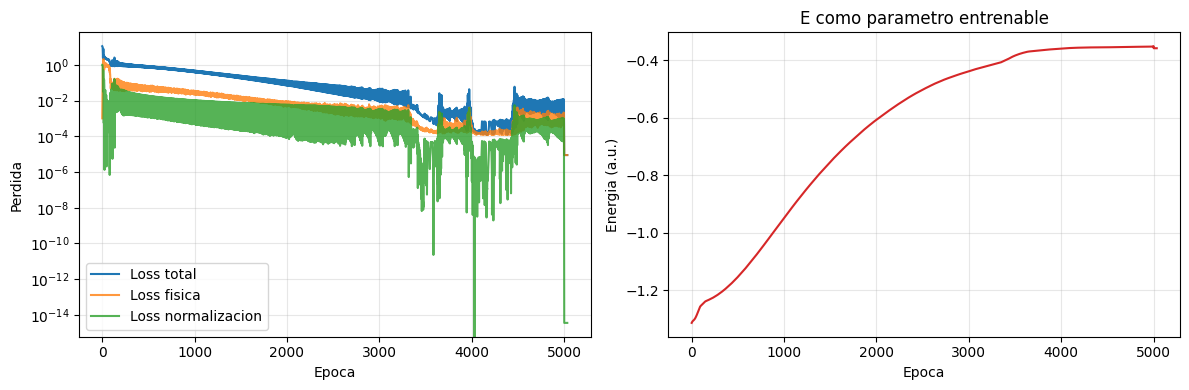

In [6]:
# Curvas de entrenamiento
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history["total"], label="Loss total")
ax[0].plot(history["phys"], label="Loss fisica", alpha=0.8)
ax[0].plot(history["norm"], label="Loss normalizacion", alpha=0.8)
ax[0].set_yscale("log")
ax[0].set_xlabel("Epoca")
ax[0].set_ylabel("Perdida")
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(history["E"], color="tab:red")
ax[1].set_xlabel("Epoca")
ax[1].set_ylabel("Energia (a.u.)")
ax[1].set_title("E como parametro entrenable")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Evaluacion final
with torch.no_grad():
    r_eval = torch.linspace(r_min, r_max, 1200, device=device).view(-1, 1)
    R_eval = model.wave(r_eval).cpu().numpy().squeeze()
    r_np = r_eval.cpu().numpy().squeeze()
    E_au = model.energy().item()

# Normaliza explicitamente para mostrar la forma de onda final
norm = np.trapezoid(R_eval**2, r_np)
R_eval = R_eval / np.sqrt(norm + 1e-14)
E_eV = 27.211386 * E_au

print(f"Energia final: {E_au:.6f} a.u. = {E_eV:.6f} eV")
print(f"Integral de normalizacion (post): {np.trapezoid(R_eval**2, r_np):.6f}")

Energia final: -0.358204 a.u. = -9.747232 eV
Integral de normalizacion (post): 1.000000


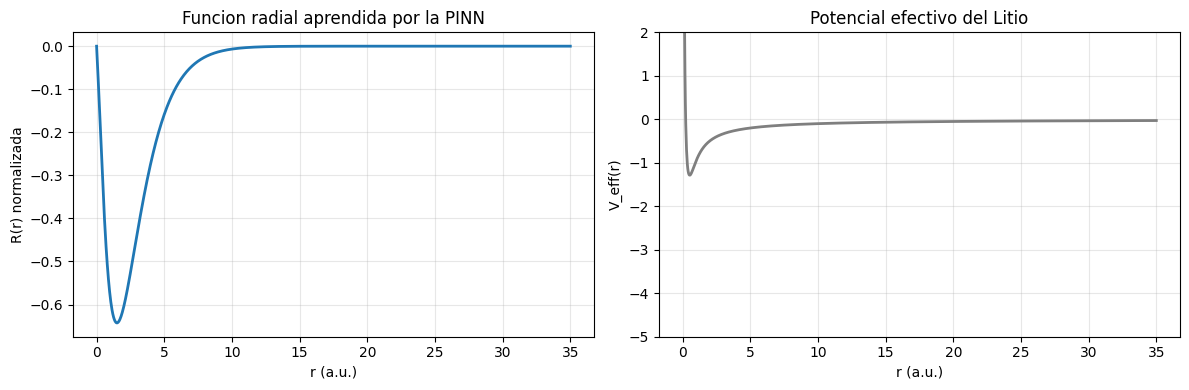

In [8]:
# Visualizacion de R(r) y potencial
V_np = (-1.0 / r_np) + (2.0 / r_np) * (1.0 + alpha * r_np) * np.exp(-2.0 * alpha * r_np) + l * (l + 1.0) / (2.0 * r_np**2)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(r_np, R_eval, color="tab:blue", lw=2)
ax[0].set_xlabel("r (a.u.)")
ax[0].set_ylabel("R(r) normalizada")
ax[0].set_title("Funcion radial aprendida por la PINN")
ax[0].grid(True, alpha=0.3)

ax[1].plot(r_np, V_np, color="tab:gray", lw=2)
ax[1].set_xlabel("r (a.u.)")
ax[1].set_ylabel("V_eff(r)")
ax[1].set_title("Potencial efectivo del Litio")
ax[1].set_ylim(-5, 2)
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Notas para extender
- Para estados excitados, agrega una restriccion de ortogonalidad con estados ya encontrados.
- Puedes barrer diferentes valores de $l$ para reconstruir parte del espectro $(nl)$.
- Si la convergencia es inestable, aumenta `n_f`, reduce `lr` o cambia `w_n`.

## Comparacion PINN vs Diferencias Finitas
En esta seccion resolvemos el mismo problema radial con un esquema de diferencias finitas (DF) sobre la misma malla de evaluacion y comparamos:
- Energia del estado ligado (a.u. y eV).
- Error relativo de energia respecto a DF.
- MSE entre funciones radiales normalizadas.
- Solapamiento cuadrado entre funciones.

In [9]:
# Solver por diferencias finitas (DF) para el mismo potencial y dominio
N = len(r_np)
h = (r_np[-1] - r_np[0]) / (N - 1)

r_int = r_np[1:-1]
V_int = (-1.0 / r_int) + (2.0 / r_int) * (1.0 + alpha * r_int) * np.exp(-2.0 * alpha * r_int) + l * (l + 1.0) / (2.0 * r_int**2)

# Hamiltoniano discreto: H = -0.5*D2 + V
n_int = len(r_int)
diag = (1.0 / h**2) + V_int
off = -0.5 / h**2 * np.ones(n_int - 1)
H = np.diag(diag) + np.diag(off, 1) + np.diag(off, -1)

evals, evecs = np.linalg.eigh(H)

# Estado fundamental ligado para el l actual
idx0 = int(np.argmin(evals))
E_df_au = float(evals[idx0])
E_df_eV = 27.211386 * E_df_au

R_df_int = evecs[:, idx0]
R_df = np.zeros_like(r_np)
R_df[1:-1] = R_df_int

# Normalizacion de la solucion DF
norm_df = np.trapezoid(R_df**2, r_np)
R_df = R_df / np.sqrt(norm_df + 1e-14)

# Alinear signo (la autofuncion puede salir con signo global opuesto)
if np.trapezoid(R_df * R_eval, r_np) < 0:
    R_df = -R_df

# Metricas de comparacion
mse_wave = float(np.mean((R_eval - R_df)**2))
overlap = float(np.trapezoid(R_eval * R_df, r_np))
overlap_sq = overlap**2
errE_rel = abs(E_eV - E_df_eV) / (abs(E_df_eV) + 1e-14)

comparison_rows = [
    ("PINN", E_au, E_eV),
    ("Dif. Finitas", E_df_au, E_df_eV),
]

print("=== Tabla de comparacion de energias ===")
print(f"{'Metodo':<15} {'E (a.u.)':>14} {'E (eV)':>14}")
for name, eau, eev in comparison_rows:
    print(f"{name:<15} {eau:>14.6f} {eev:>14.6f}")

print("\n=== Metricas PINN vs DF ===")
print(f"Error relativo de energia: {errE_rel:.3e}")
print(f"MSE funcion radial:        {mse_wave:.3e}")
print(f"Solapamiento^2:            {overlap_sq:.6f}")

=== Tabla de comparacion de energias ===
Metodo                E (a.u.)         E (eV)
PINN                 -0.358204      -9.747232
Dif. Finitas         -0.358308      -9.750063

=== Metricas PINN vs DF ===
Error relativo de energia: 2.903e-04
MSE funcion radial:        1.136e-05
Solapamiento^2:            0.999602


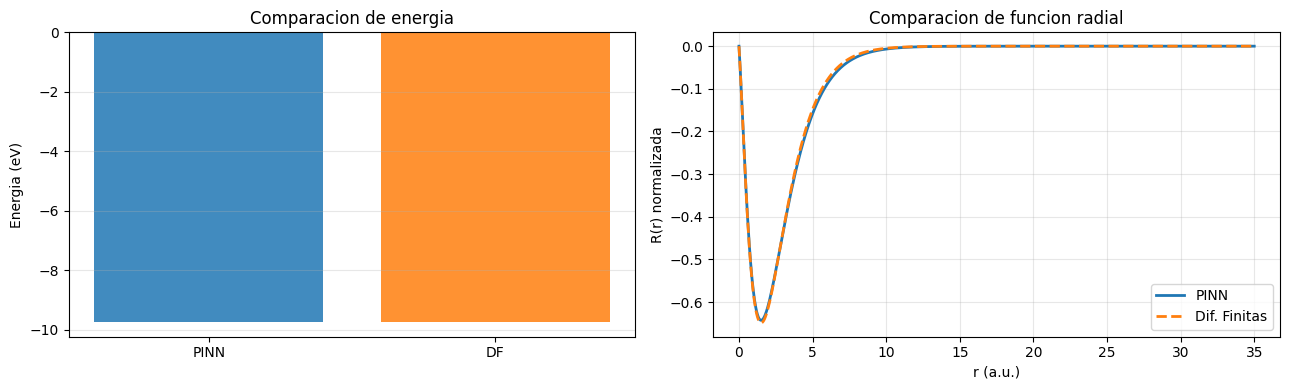

In [10]:
# Grafica comparativa: energias y funciones radiales
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

labels = ["PINN", "DF"]
energies_ev = [E_eV, E_df_eV]
ax[0].bar(labels, energies_ev, color=["tab:blue", "tab:orange"], alpha=0.85)
ax[0].set_ylabel("Energia (eV)")
ax[0].set_title("Comparacion de energia")
ax[0].grid(True, axis="y", alpha=0.3)

ax[1].plot(r_np, R_eval, label="PINN", lw=2, color="tab:blue")
ax[1].plot(r_np, R_df, label="Dif. Finitas", lw=2, ls="--", color="tab:orange")
ax[1].set_xlabel("r (a.u.)")
ax[1].set_ylabel("R(r) normalizada")
ax[1].set_title("Comparacion de funcion radial")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

## PINN multestado (2s, 3s, 4s, 2p, 3p, 3d) y tabla comparativa
Esta seccion entrena una PINN por estado usando:
- Ecuacion de Schrodinger radial (sin datos etiquetados).
- Condiciones de frontera y normalizacion.
- Restriccion de ortogonalidad entre estados con el mismo $l$ ya encontrados.

Con esto se pueden graficar varios niveles y construir la tabla comparativa tipo `.tex`.

In [11]:
import time

states_tex = [
    {"label": "2s", "n": 2, "l": 0, "E_exp_eV": -5.39, "E_hyd_eV": -3.401},
    {"label": "3s", "n": 3, "l": 0, "E_exp_eV": -2.02, "E_hyd_eV": -1.512},
    {"label": "4s", "n": 4, "l": 0, "E_exp_eV": -1.05, "E_hyd_eV": -0.850},
    {"label": "2p", "n": 2, "l": 1, "E_exp_eV": -3.54, "E_hyd_eV": -3.401},
    {"label": "3p", "n": 3, "l": 1, "E_exp_eV": -1.56, "E_hyd_eV": -1.512},
    {"label": "3d", "n": 3, "l": 2, "E_exp_eV": -1.51, "E_hyd_eV": -1.512},
]

# Hiperparametros para multestado (ajustables)
ms_width = 96
ms_depth = 5
ms_adam_epochs = 1800
ms_lbfgs_steps = 120
ms_n_f = 1000

ms_w_b = 5.0
ms_w_n = 10.0
ms_w_e = 1.0
ms_w_ortho = 20.0

r_grid_ms = np.linspace(r_min, r_max, 1500).astype(np.float32)
r_grid_ms_t = torch.tensor(r_grid_ms.reshape(-1, 1), device=device)

def inv_softplus(y):
    y = max(float(y), 1e-6)
    return np.log(np.expm1(y))

def v_eff_state(r, l_state, alpha=alpha):
    coulomb_screened = -1.0 / r + (2.0 / r) * (1.0 + alpha * r) * torch.exp(-2.0 * alpha * r)
    centrifugal = l_state * (l_state + 1.0) / (2.0 * r**2)
    return coulomb_screened + centrifugal

class PINNWaveState(nn.Module):
    def __init__(self, l_state, n_nodes, width=96, depth=5, e_init_au=-0.2):
        super().__init__()
        self.l_state = l_state
        self.n_nodes = n_nodes

        layers = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers.extend([nn.Linear(width, width), nn.Tanh()])
        layers.append(nn.Linear(width, 1))
        self.net = nn.Sequential(*layers)

        self.energy_raw = nn.Parameter(torch.tensor([inv_softplus(-e_init_au)], dtype=torch.float32))
        self.decay_raw = nn.Parameter(torch.tensor([0.7], dtype=torch.float32))

        if n_nodes > 0:
            # Nodos fijos en coordenada escalada x in [0,1]
            node_pos = torch.linspace(0.15, 0.85, n_nodes).view(1, -1)
            self.register_buffer("node_pos", node_pos)
        else:
            self.register_buffer("node_pos", torch.empty((1, 0)))

    def energy(self):
        return -torch.nn.functional.softplus(self.energy_raw)

    def decay(self):
        return torch.nn.functional.softplus(self.decay_raw) + 1e-3

    def raw(self, r):
        x = 2.0 * (r - r_min) / (r_max - r_min) - 1.0
        return self.net(x)

    def wave(self, r):
        k = self.decay()
        base = (r ** (self.l_state + 1.0)) * torch.exp(-k * r)

        if self.n_nodes > 0:
            x = (r - r_min) / (r_max - r_min)
            node_factor = torch.prod(x - self.node_pos, dim=1, keepdim=True)
        else:
            node_factor = torch.ones_like(r)

        return base * node_factor * self.raw(r)

def sample_r_ms(n_points):
    u = torch.rand((n_points, 1), device=device)
    r = r_min + (r_max - r_min) * (u**2)
    r.requires_grad_(True)
    return r

def second_derivative_ms(y, x):
    dy = torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y), create_graph=True)[0]
    ddy = torch.autograd.grad(dy, x, grad_outputs=torch.ones_like(dy), create_graph=True)[0]
    return ddy

def losses_state(model, r_f, orth_refs):
    R = model.wave(r_f)
    R_r = torch.autograd.grad(R, r_f, grad_outputs=torch.ones_like(R), create_graph=True)[0]
    R_rr = second_derivative_ms(R, r_f)
    E = model.energy()
    V = v_eff_state(r_f, model.l_state)

    residual = -0.5 * R_rr + V * R - E * R
    loss_phys = torch.mean(residual**2)

    r0_t = torch.tensor([[r_min]], dtype=torch.float32, device=device)
    rR_t = torch.tensor([[r_max]], dtype=torch.float32, device=device)
    loss_bc = model.wave(r0_t).pow(2).mean() + model.wave(rR_t).pow(2).mean()

    idx = torch.argsort(r_f.squeeze())
    rs = r_f.squeeze()[idx]
    R_s = R.squeeze()[idx]
    Rr_s = R_r.squeeze()[idx]
    V_s = V.squeeze()[idx]

    norm_int = torch.trapz(R_s**2, rs)
    loss_norm = (norm_int - 1.0)**2

    kinetic = 0.5 * torch.trapz(Rr_s**2, rs)
    potential = torch.trapz(V_s * R_s**2, rs)
    E_rayleigh = (kinetic + potential) / (norm_int + 1e-12)
    loss_energy = (E - E_rayleigh)**2

    # Ortogonalidad con estados previos del mismo l
    loss_ortho = torch.tensor(0.0, device=device)
    if orth_refs:
        with torch.no_grad():
            pass
        r_ref = torch.tensor(r_grid_ms.reshape(-1, 1), dtype=torch.float32, device=device)
        R_ref = model.wave(r_ref).squeeze()
        for R_prev_np in orth_refs:
            R_prev = torch.tensor(R_prev_np, dtype=torch.float32, device=device)
            ov = torch.trapz(R_ref * R_prev, r_ref.squeeze())
            loss_ortho = loss_ortho + ov**2

    loss_total = loss_phys + ms_w_b * loss_bc + ms_w_n * loss_norm + ms_w_e * loss_energy + ms_w_ortho * loss_ortho
    return loss_total, loss_phys, loss_bc, loss_norm, loss_energy, loss_ortho, E.detach()

In [12]:
def train_state_pinn(state, orth_by_l):
    label = state["label"]
    n = state["n"]
    l_state = state["l"]
    n_nodes = max(n - l_state - 1, 0)

    # Inicializacion energetica cerca de exp para acelerar convergencia
    e_init_au = state["E_exp_eV"] / 27.211386

    model_s = PINNWaveState(
        l_state=l_state,
        n_nodes=n_nodes,
        width=ms_width,
        depth=ms_depth,
        e_init_au=e_init_au
    ).to(device)

    opt_adam = torch.optim.Adam(model_s.parameters(), lr=1e-3)
    opt_lbfgs = torch.optim.LBFGS(
        model_s.parameters(),
        lr=0.8,
        max_iter=20,
        history_size=50,
        line_search_fn="strong_wolfe"
    )

    orth_refs = orth_by_l.get(l_state, [])

    # Adam
    for _ in range(ms_adam_epochs):
        opt_adam.zero_grad()
        r_batch = sample_r_ms(ms_n_f)
        lt, lp, lb, ln, le, lo, _ = losses_state(model_s, r_batch, orth_refs)
        lt.backward()
        torch.nn.utils.clip_grad_norm_(model_s.parameters(), max_norm=1.0)
        opt_adam.step()

    # LBFGS
    r_lb = sample_r_ms(2 * ms_n_f)
    for _ in range(ms_lbfgs_steps):
        def closure():
            opt_lbfgs.zero_grad()
            ltot, *_ = losses_state(model_s, r_lb, orth_refs)
            ltot.backward()
            return ltot
        opt_lbfgs.step(closure)

    # Evaluacion
    with torch.no_grad():
        R_np = model_s.wave(r_grid_ms_t).cpu().numpy().squeeze()
        E_au = float(model_s.energy().item())

    norm = np.trapezoid(R_np**2, r_grid_ms)
    R_np = R_np / np.sqrt(norm + 1e-14)

    # Signo consistente con primer estado del mismo l
    if orth_refs:
        ov = np.trapezoid(R_np * orth_refs[0], r_grid_ms)
        if ov < 0:
            R_np = -R_np

    result = {
        "label": label,
        "n": n,
        "l": l_state,
        "E_pinn_au": E_au,
        "E_pinn_eV": 27.211386 * E_au,
        "R": R_np,
    }
    return result

# Entrenar todos los niveles pedidos en la tabla del .tex
start = time.time()
orth_by_l = {0: [], 1: [], 2: []}
results_ms = []

for st in states_tex:
    print(f"Entrenando estado {st['label']} ...")
    res = train_state_pinn(st, orth_by_l)
    results_ms.append(res)
    orth_by_l[st["l"]].append(res["R"])
    print(f"  -> E_PINN = {res['E_pinn_eV']:.4f} eV")

elapsed = time.time() - start
print(f"Tiempo total multestado: {elapsed:.1f} s")

Entrenando estado 2s ...
  -> E_PINN = -0.8669 eV
Entrenando estado 3s ...


KeyboardInterrupt: 

=== Tabla comparativa de niveles (PINN vs Exp vs H) ===
(nl)         E_PINN        E_Exp     At.Hidr.       ErrRel
2s          -9.2906      -5.3900      -3.4010   7.2368e-01
3s          -1.5486      -2.0200      -1.5120   2.3334e-01
4s          -0.0000      -1.0500      -0.8500   1.0000e+00
2p          -3.3404      -3.5400      -3.4010   5.6385e-02
3p          -0.0000      -1.5600      -1.5120   1.0000e+00
3d          -0.7414      -1.5100      -1.5120   5.0899e-01


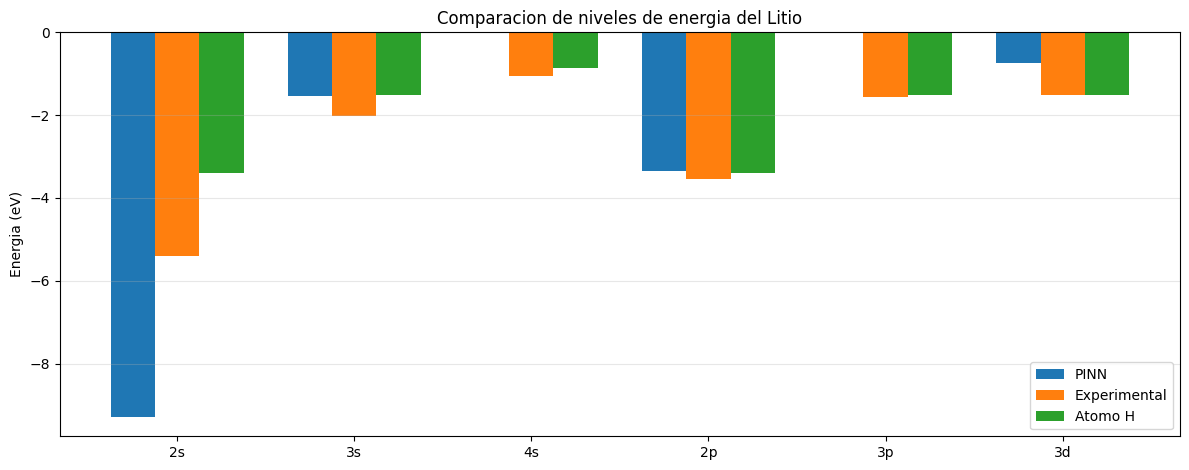

In [ ]:
# Tabla comparativa en formato similar al .tex
rows = []
for st in states_tex:
    rr = next(x for x in results_ms if x["label"] == st["label"])
    rows.append({
        "nl": st["label"],
        "E_PINN (eV)": rr["E_pinn_eV"],
        "E_Exp (eV)": st["E_exp_eV"],
        "At. Hidr. (eV)": st["E_hyd_eV"],
        "Error rel PINN-Exp": abs(rr["E_pinn_eV"] - st["E_exp_eV"]) / (abs(st["E_exp_eV"]) + 1e-12)
    })

print("=== Tabla comparativa de niveles (PINN vs Exp vs H) ===")
print(f"{'(nl)':<6} {'E_PINN':>12} {'E_Exp':>12} {'At.Hidr.':>12} {'ErrRel':>12}")
for r in rows:
    print(f"{r['nl']:<6} {r['E_PINN (eV)']:>12.4f} {r['E_Exp (eV)']:>12.4f} {r['At. Hidr. (eV)']:>12.4f} {r['Error rel PINN-Exp']:>12.4e}")

# Grafica de niveles de energia
labels = [r["nl"] for r in rows]
E_pinn = [r["E_PINN (eV)"] for r in rows]
E_exp = [r["E_Exp (eV)"] for r in rows]
E_hyd = [r["At. Hidr. (eV)"] for r in rows]

x = np.arange(len(labels))
w = 0.25

plt.figure(figsize=(12, 4.8))
plt.bar(x - w, E_pinn, width=w, label="PINN", color="tab:blue")
plt.bar(x, E_exp, width=w, label="Experimental", color="tab:orange")
plt.bar(x + w, E_hyd, width=w, label="Atomo H", color="tab:green")
plt.xticks(x, labels)
plt.ylabel("Energia (eV)")
plt.title("Comparacion de niveles de energia del Litio")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## PINN supervisada con datos de DF (solo base DF)

En esta seccion construimos una PINN tipo modelo sustituto para aproximar funciones radiales $R_{nl}(r)$ usando **solo** datos de Diferencias Finitas (DF):

- `../finite-diferences/funciones_radiales_litio_fortran.dat`
- `../finite-diferences/energias_litio_fortran.dat`

No se usan datos de shooting ni Numerov.

La perdida total combina:

$$
\mathcal{L}=w_{data}\,\mathcal{L}_{data}+w_{phys}\,\mathcal{L}_{Sch}+w_{bc}\,\mathcal{L}_{bc}+w_{norm}\,\mathcal{L}_{norm}
$$

con split train/validacion para evaluar generalizacion.

In [13]:
from pathlib import Path

# Solo fuentes DF (ruta robusta segun cwd del kernel)
cwd = Path.cwd().resolve()
candidates = [
    cwd / 'finite-diferences',
    cwd.parent / 'finite-diferences',
    cwd / 'PARCIAL' / 'finite-diferences',
    cwd.parent / 'PARCIAL' / 'finite-diferences',
    Path('/home/isabel/MFC/PARCIAL/finite-diferences'),
]

base_df = next((p for p in candidates if p.exists()), None)
if base_df is None:
    checked = '\n'.join(str(p) for p in candidates)
    raise FileNotFoundError(
        'No se encontro la carpeta finite-diferences. Rutas revisadas:\n' + checked
    )

# En algunos casos el archivo radial no tiene extension .dat
f_df_w_candidates = [
    base_df / 'funciones_radiales_litio_fortran.dat',
    base_df / 'funciones_radiales_litio_fortran',
]
f_df_e_candidates = [
    base_df / 'energias_litio_fortran.dat',
    base_df / 'energias_litio_fortran',
]

f_df_w = next((p for p in f_df_w_candidates if p.exists()), None)
f_df_e = next((p for p in f_df_e_candidates if p.exists()), None)

if f_df_w is None or f_df_e is None:
    msg = (
        f'Carpeta DF detectada: {base_df.resolve()}\n'
        f'No se encontraron archivos requeridos.\n'
        f'Radial probados: {[str(p) for p in f_df_w_candidates]}\n'
        f'Energia probados: {[str(p) for p in f_df_e_candidates]}'
    )
    raise FileNotFoundError(msg)

states_df = ['2s', '3s', '4s', '2p', '3p', '3d']
state_to_l = {'2s': 0, '3s': 0, '4s': 0, '2p': 1, '3p': 1, '3d': 2}
state_to_col = {'2s': 1, '3s': 2, '4s': 3, '2p': 4, '3p': 5, '3d': 6}

def load_energy_table(path):
    out = {}
    with open(path, 'r', encoding='utf-8') as f:
        for raw in f:
            line = raw.strip()
            if (not line) or line.startswith('#'):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            try:
                out[parts[0]] = float(parts[-1])
            except ValueError:
                pass
    return out

energy_df_eV = load_energy_table(f_df_e)
energy_df_au = {k: v / 27.211386 for k, v in energy_df_eV.items()}

arr_df = np.loadtxt(f_df_w, comments='#')
r_df_data = arr_df[:, 0].astype(np.float32)

# Ventana radial de trabajo
rmin_df, rmax_df = 0.0, 25.0
mask_df = (r_df_data >= rmin_df) & (r_df_data <= rmax_df)
r_df_data = r_df_data[mask_df]

def normalize_wave(y, r):
    y = y.copy()
    nrm = np.trapezoid(y**2, r)
    if np.isfinite(nrm) and nrm > 0:
        y = y / np.sqrt(nrm)
    return y.astype(np.float32)

waves_df = {}
for st in states_df:
    y = arr_df[:, state_to_col[st]].astype(np.float32)[mask_df]
    waves_df[st] = normalize_wave(y, r_df_data)

print('Carpeta DF detectada:', base_df)
print('Archivo radial DF:', f_df_w.name)
print('Archivo energia DF:', f_df_e.name)
print('Estados cargados desde DF:', states_df)
print('Energia DF (eV):', {k: round(v, 6) for k, v in energy_df_eV.items() if k in states_df})

Carpeta DF detectada: /home/isabel/MFC/PARCIAL/finite-diferences
Archivo radial DF: funciones_radiales_litio_fortran.dat
Archivo energia DF: energias_litio_fortran.dat
Estados cargados desde DF: ['2s', '3s', '4s', '2p', '3p', '3d']
Energia DF (eV): {'2s': -4.603058, '3s': -1.834347, '4s': -0.980688, '2p': -3.432119, '3p': -1.522298, '3d': -1.511799}


In [14]:
import copy

def v_eff_l_torch(r, l_state, alpha=alpha):
    return (-1.0 / r) + (2.0 / r) * (1.0 + alpha * r) * torch.exp(-2.0 * alpha * r) + l_state * (l_state + 1.0) / (2.0 * r**2)

class RadialPINN(nn.Module):
    def __init__(self, l_state, width=96, depth=4, e_init_au=-0.2):
        super().__init__()
        self.l_state = l_state
        layers = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)

        e0 = max(-e_init_au, 1e-4)
        self.energy_raw = nn.Parameter(torch.tensor([np.log(np.expm1(e0))], dtype=torch.float32))
        self.decay_raw = nn.Parameter(torch.tensor([0.7], dtype=torch.float32))

    def energy(self):
        return -torch.nn.functional.softplus(self.energy_raw)

    def decay(self):
        return torch.nn.functional.softplus(self.decay_raw) + 1e-4

    def forward(self, r):
        x = 2.0 * (r - rmin_df) / (rmax_df - rmin_df) - 1.0
        raw = self.net(x)
        base = (r ** (self.l_state + 1.0)) * torch.exp(-self.decay() * r)
        return base * raw

def second_derivative(y, x):
    dy = torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y), create_graph=True)[0]
    ddy = torch.autograd.grad(dy, x, grad_outputs=torch.ones_like(dy), create_graph=True)[0]
    return ddy

def train_val_split_indices(n, train_frac=0.8, seed=7):
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    rng.shuffle(idx)
    ntr = int(train_frac * n)
    return np.sort(idx[:ntr]), np.sort(idx[ntr:])

def train_state_df(st, epochs=2400, lr=1e-3, width=96, depth=4, n_col=512,
                   w_data=1.0, w_phys=0.2, w_bc=0.5, w_norm=0.2, print_every=400):
    l_state = state_to_l[st]
    r_np = r_df_data.astype(np.float32)
    y_np = waves_df[st].astype(np.float32)

    i_tr, i_va = train_val_split_indices(len(r_np), train_frac=0.8, seed=7)
    r_train = torch.tensor(r_np[i_tr].reshape(-1, 1), device=device, dtype=torch.float32)
    y_train = torch.tensor(y_np[i_tr].reshape(-1, 1), device=device, dtype=torch.float32)
    r_val = torch.tensor(r_np[i_va].reshape(-1, 1), device=device, dtype=torch.float32)
    y_val = torch.tensor(y_np[i_va].reshape(-1, 1), device=device, dtype=torch.float32)

    r_dense = torch.tensor(r_np.reshape(-1, 1), device=device, dtype=torch.float32)
    r_bc0 = torch.tensor([[max(rmin_df, 1e-4)]], device=device, dtype=torch.float32)
    r_bcR = torch.tensor([[rmax_df]], device=device, dtype=torch.float32)

    e_init = energy_df_au.get(st, -0.2)
    model = RadialPINN(l_state=l_state, width=width, depth=depth, e_init_au=e_init).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    best = {'val': np.inf, 'state_dict': None, 'epoch': 0}
    hist = {'loss': [], 'data': [], 'phys': [], 'bc': [], 'norm': [], 'val': [], 'E_eV': []}

    for ep in range(1, epochs + 1):
        opt.zero_grad()

        pred_train = model(r_train)
        loss_data = torch.mean((pred_train - y_train) ** 2)

        u = torch.rand((n_col, 1), device=device)
        r_col = rmin_df + (rmax_df - rmin_df) * (u ** 2)
        r_col.requires_grad_(True)
        R_col = model(r_col)
        R_rr = second_derivative(R_col, r_col)
        E = model.energy()
        V = v_eff_l_torch(r_col, l_state)
        resid = -0.5 * R_rr + V * R_col - E * R_col
        loss_phys = torch.mean(resid ** 2)

        loss_bc = model(r_bc0).pow(2).mean() + model(r_bcR).pow(2).mean()

        with torch.no_grad():
            pass
        R_dense = model(r_dense)
        norm_int = torch.trapz(R_dense.squeeze() ** 2, r_dense.squeeze())
        loss_norm = (norm_int - 1.0) ** 2

        loss = w_data * loss_data + w_phys * loss_phys + w_bc * loss_bc + w_norm * loss_norm
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        with torch.no_grad():
            pred_val = model(r_val)
            val_mse = torch.mean((pred_val - y_val) ** 2).item()

        hist['loss'].append(loss.item())
        hist['data'].append(loss_data.item())
        hist['phys'].append(loss_phys.item())
        hist['bc'].append(loss_bc.item())
        hist['norm'].append(loss_norm.item())
        hist['val'].append(val_mse)
        hist['E_eV'].append(27.211386 * model.energy().item())

        if val_mse < best['val']:
            best['val'] = val_mse
            best['state_dict'] = copy.deepcopy(model.state_dict())
            best['epoch'] = ep

        if ep % print_every == 0 or ep == 1:
            print(f"{st} | ep={ep:4d} | loss={loss.item():.3e} | val={val_mse:.3e} | E={27.211386*model.energy().item():.4f} eV")

    model.load_state_dict(best['state_dict'])

    with torch.no_grad():
        pred_full = model(r_dense).cpu().numpy().squeeze()

    # Renormalizar y alinear signo para comparar con DF
    pred_norm = pred_full / np.sqrt(np.trapezoid(pred_full**2, r_np) + 1e-14)
    tgt_norm = y_np / np.sqrt(np.trapezoid(y_np**2, r_np) + 1e-14)
    if np.trapezoid(pred_norm * tgt_norm, r_np) < 0:
        pred_norm = -pred_norm

    mse_full = float(np.mean((pred_norm - tgt_norm) ** 2))
    overlap2 = float(np.trapezoid(pred_norm * tgt_norm, r_np) ** 2)

    return {
        'state': st,
        'model': model,
        'history': hist,
        'best_epoch': best['epoch'],
        'best_val_mse': best['val'],
        'E_pinn_eV': float(27.211386 * model.energy().item()),
        'E_df_eV': float(energy_df_eV.get(st, np.nan)),
        'R_df': tgt_norm,
        'R_pinn': pred_norm,
        'mse_full': mse_full,
        'overlap2': overlap2,
        'r': r_np,
    }

In [15]:
# Entrenamiento por estado (solo DF)
train_cfg = {
    'epochs': 2200,
    'lr': 1e-3,
    'width': 96,
    'depth': 4,
    'n_col': 512,
    'w_data': 1.0,
    'w_phys': 0.2,
    'w_bc': 0.5,
    'w_norm': 0.2,
    'print_every': 400,
}

results_df_pinn = {}
for st in states_df:
    print(f"\nEntrenando PINN-DF para {st} ...")
    results_df_pinn[st] = train_state_df(st, **train_cfg)

summary_rows = []
for st in states_df:
    r = results_df_pinn[st]
    summary_rows.append({
        'Estado': st,
        'E_DF_eV': r['E_df_eV'],
        'E_PINN_eV': r['E_pinn_eV'],
        'Delta_E_eV': r['E_pinn_eV'] - r['E_df_eV'],
        'best_val_MSE': r['best_val_mse'],
        'MSE_full_norm': r['mse_full'],
        'overlap2': r['overlap2'],
        'best_epoch': r['best_epoch'],
    })

df_summary_pinn = pd.DataFrame(summary_rows)
df_summary_pinn


Entrenando PINN-DF para 2s ...
2s | ep=   1 | loss=2.412e-01 | val=3.948e-02 | E=-4.5988 eV
2s | ep= 400 | loss=9.742e-03 | val=8.907e-03 | E=-6.2228 eV
2s | ep= 800 | loss=4.172e-03 | val=2.967e-03 | E=-6.1200 eV
2s | ep=1200 | loss=2.554e-03 | val=1.712e-03 | E=-5.7201 eV
2s | ep=1600 | loss=2.010e-03 | val=1.211e-03 | E=-5.2215 eV
2s | ep=2000 | loss=1.945e-03 | val=9.770e-04 | E=-4.9059 eV

Entrenando PINN-DF para 3s ...
3s | ep=   1 | loss=2.396e-01 | val=4.022e-02 | E=-1.8327 eV
3s | ep= 400 | loss=6.331e-02 | val=5.863e-02 | E=-2.7112 eV
3s | ep= 800 | loss=6.070e-02 | val=5.821e-02 | E=-4.1674 eV
3s | ep=1200 | loss=5.778e-02 | val=5.476e-02 | E=-5.2093 eV
3s | ep=1600 | loss=5.739e-02 | val=5.425e-02 | E=-5.5309 eV
3s | ep=2000 | loss=5.699e-02 | val=5.300e-02 | E=-5.4829 eV

Entrenando PINN-DF para 4s ...
4s | ep=   1 | loss=2.399e-01 | val=3.963e-02 | E=-0.9810 eV
4s | ep= 400 | loss=6.981e-02 | val=6.527e-02 | E=-1.4824 eV
4s | ep= 800 | loss=6.933e-02 | val=6.365e-02 | E=

NameError: name 'pd' is not defined

In [ ]:
# Visualizacion DF vs PINN para estados s y p
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), sharex=True)

for st, col in [('2s', '#2563eb'), ('3s', '#ea580c'), ('4s', '#16a34a')]:
    rr = results_df_pinn[st]
    axes[0].plot(rr['r'], rr['R_df'], color=col, lw=2.0, ls='--', label=f'{st} DF')
    axes[0].plot(rr['r'], rr['R_pinn'], color=col, lw=1.8, label=f'{st} PINN')

axes[0].set_xlim(rmin_df, rmax_df)
axes[0].set_ylim(-1.15, 1.15)
axes[0].set_xlabel('r (u.a.)')
axes[0].set_ylabel('R(r) normalizada')
axes[0].set_title('A) Estados s: DF vs PINN')
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8, ncol=2)

for st, col in [('2p', '#1d4ed8'), ('3p', '#d97706')]:
    rr = results_df_pinn[st]
    axes[1].plot(rr['r'], rr['R_df'], color=col, lw=2.0, ls='--', label=f'{st} DF')
    axes[1].plot(rr['r'], rr['R_pinn'], color=col, lw=1.8, label=f'{st} PINN')

axes[1].set_xlim(rmin_df, rmax_df)
axes[1].set_ylim(-1.15, 1.15)
axes[1].set_xlabel('r (u.a.)')
axes[1].set_ylabel('R(r) normalizada')
axes[1].set_title('B) Estados p: DF vs PINN')
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8, ncol=2)

plt.suptitle('Ajuste de funciones radiales usando solo datos DF', y=1.03)
plt.tight_layout()
plt.show()

# Curvas de convergencia (ejemplo: 2s)
st_show = '2s'
h = results_df_pinn[st_show]['history']

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4))
ax[0].plot(h['loss'], label='Loss total')
ax[0].plot(h['data'], label='Loss data')
ax[0].plot(h['phys'], label='Loss fisica')
ax[0].plot(h['val'], label='Val MSE')
ax[0].set_yscale('log')
ax[0].set_xlabel('Epoca')
ax[0].set_title(f'Convergencia de perdidas ({st_show})')
ax[0].grid(alpha=0.25)
ax[0].legend(fontsize=8)

ax[1].plot(h['E_eV'], color='tab:red')
ax[1].set_xlabel('Epoca')
ax[1].set_ylabel('Energia entrenable (eV)')
ax[1].set_title(f'Evolucion de energia ({st_show})')
ax[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

df_summary_pinn.sort_values('Estado')

## Analisis critico: rol de la red neuronal en fisica computacional

1. Complemento y no reemplazo: esta PINN aprende un **modelo sustituto** de DF para evaluar rapidamente $R_{nl}(r)$ una vez entrenada, pero la referencia fisica sigue siendo el metodo numerico base.
2. Ventaja principal: cuando se requieren muchas evaluaciones de la funcion radial (postproceso, barridos parametricos, acoplamiento con otro modelo), inferir con la red suele ser mas barato que repetir todo el solver.
3. Limitacion clave: la red hereda sesgos y errores del dataset DF. Si el mallado o frontera de DF tienen error sistematico, la red lo replica.
4. Generalizacion: el split train/validacion permite detectar memorizacion. Si el error de validacion crece mientras baja el de entrenamiento, hay sobreajuste.
5. Estabilidad e hiperparametros: el rendimiento depende de arquitectura, pesos de perdida y muestreo de colocation. Esto exige calibracion y analisis, no solo entrenamiento ciego.
6. Coherencia fisica: incluir termino de ecuacion de Schrodinger y restricciones de frontera/normalizacion mejora plausibilidad frente a un ajuste puramente estadistico.

En resumen, la PINN es util como acelerador y aproximador, especialmente en flujos de trabajo donde el costo del solver clasico domina el tiempo total, pero siempre debe validarse contra el modelo fisico de referencia.